# CSE498R Research — Dual Prediction Platform
## Academic Performance Predictor + Mental Health Predictor

**Dataset:** `student_data.csv` (200,000 rows × 15 columns)  
**Targets:**
- 🎓 **Platform 1** → `average_score` (regression) + `pass_fail` (classification)
- 🧠 **Platform 2** → `stress_level` (regression) + `stress_category` (classification)

**Metrics:** MSE · RMSE · MAE · R² (target R² ≥ 0.90 for academic platform)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor, RandomForestClassifier,
    GradientBoostingRegressor, GradientBoostingClassifier,
    ExtraTreesRegressor, ExtraTreesClassifier, StackingRegressor
)
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

import tensorflow as tf
from tensorflow.keras import layers, Model

print("Libraries loaded ✔")
print(f"TensorFlow: {tf.__version__}")


2026-06-02 02:45:22.294073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780368322.665181      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780368322.771977      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780368323.695416      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780368323.695475      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780368323.695478      16 computation_placer.cc:177] computation placer alr

Libraries loaded ✔
TensorFlow: 2.19.0


## 1. Data Loading & Exploration

In [2]:

df = pd.read_csv("/kaggle/input/datasets/sakib2004/student/student_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (200000, 15)


,gender,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,private_tutoring,internet_quality,math_score,reading_score,writing_score,pass_fail
0,Female,15,2,45000.0,2.9,0.916,8.3,6.0,16,False,2,21,29,29,Fail
1,Male,19,2,15000.0,2.8,0.760,6.8,5.0,58,False,3,56,37,45,Fail
2,Female,20,5,55000.0,4.0,0.894,8.2,6.0,51,False,3,60,51,63,Fail
3,Female,16,5,65000.0,4.6,0.888,6.2,6.0,49,False,3,58,54,34,Fail
4,Male,20,4,35000.0,4.3,0.923,7.3,4.0,62,False,2,80,57,73,Pass


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   gender                    200000 non-null  object 
 1   age                       200000 non-null  int64  
 2   parental_education_level  200000 non-null  int64  
 3   family_income             195975 non-null  float64
 4   daily_study_hours         200000 non-null  float64
 5   attendance_rate           200000 non-null  float64
 6   sleep_hours               195887 non-null  float64
 7   stress_level              196087 non-null  float64
 8   motivation_score          200000 non-null  int64  
 9   private_tutoring          200000 non-null  bool   
 10  internet_quality          200000 non-null  int64  
 11  math_score                200000 non-null  int64  
 12  reading_score             200000 non-null  int64  
 13  writing_score             200000 non-null  i

In [4]:
df.describe().round(2)


,age,parental_education_level,family_income,daily_study_hours,attendance_rate,sleep_hours,stress_level,motivation_score,internet_quality,math_score,reading_score,writing_score
count,200000.00,200000.00,195975.00,200000.00,200000.00,195887.00,196087.00,200000.00,200000.00,200000.00,200000.00,200000.00
mean,18.15,3.69,51446.03,3.75,0.89,7.71,5.10,48.58,2.91,62.97,62.51,61.00
std,1.65,1.61,36071.00,0.83,0.06,0.93,1.46,13.64,0.72,17.07,18.04,17.14
min,15.00,1.00,15000.00,2.30,0.58,4.00,1.00,10.00,1.00,0.00,0.00,0.00
25%,17.00,2.00,25000.00,3.20,0.85,7.10,4.00,39.00,2.00,51.00,50.00,49.00
50%,18.00,4.00,40000.00,3.60,0.90,7.70,5.00,49.00,3.00,63.00,62.00,61.00
75%,19.00,5.00,65000.00,4.20,0.94,8.30,6.00,58.00,3.00,75.00,75.00,73.00
max,22.00,7.00,400000.00,8.00,1.00,11.00,10.00,100.00,5.00,100.00,100.00,100.00


In [5]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")


Missing Values:
gender                         0
age                            0
parental_education_level       0
family_income               4025
daily_study_hours              0
attendance_rate                0
sleep_hours                 4113
stress_level                3913
motivation_score               0
private_tutoring               0
internet_quality               0
math_score                     0
reading_score                  0
writing_score                  0
pass_fail                      0
dtype: int64

Total missing: 12051


## 2. Target Variable Analysis (Both Platforms)

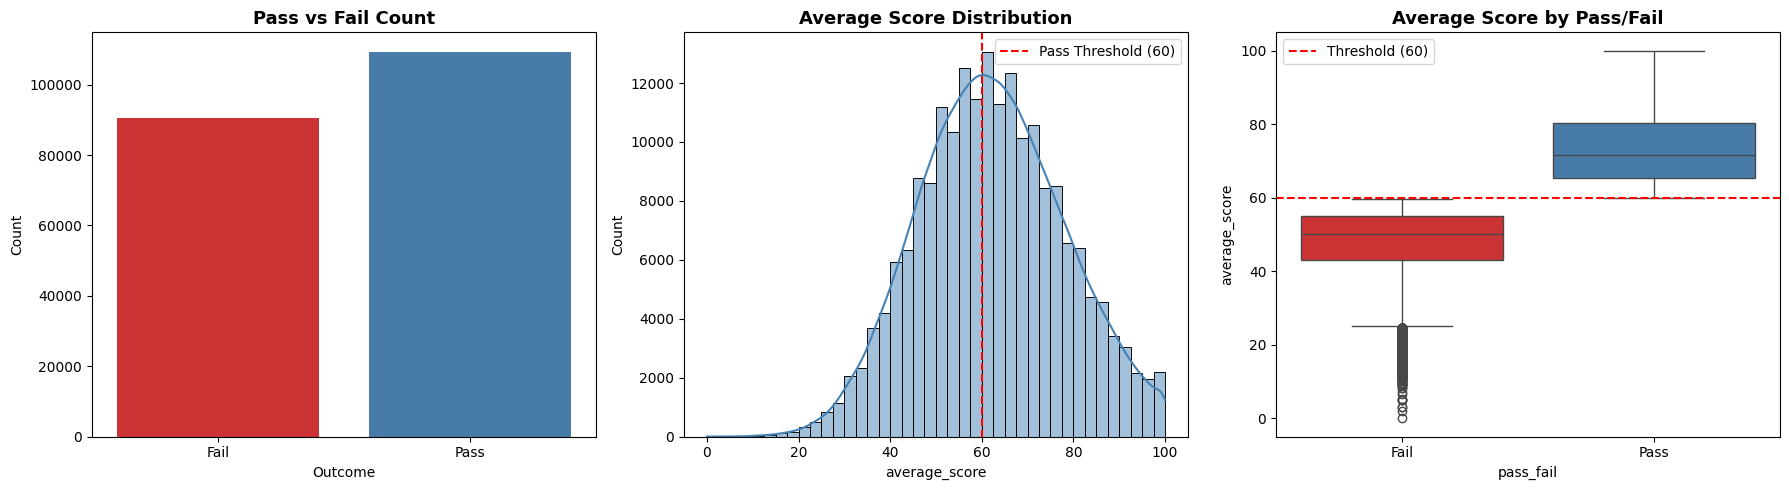

Pass threshold: avg_score >= 60 (min pass: 60.00)
Pass rate: 54.7%


In [ ]:
# platform1
df['average_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pass/Fail distribution
sns.countplot(x='pass_fail', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Pass vs Fail Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Outcome'); axes[0].set_ylabel('Count')

# Average score distribution
sns.histplot(data=df, x='average_score', bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(60, color='red', linestyle='--', label='Pass Threshold (60)')
axes[1].set_title('Average Score Distribution', fontsize=13, fontweight='bold')
axes[1].legend()

# Average score by pass/fail
sns.boxplot(data=df, x='pass_fail', y='average_score', palette='Set1', ax=axes[2])
axes[2].axhline(60, color='red', linestyle='--', label='Threshold (60)')
axes[2].set_title('Average Score by Pass/Fail', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout(); plt.show()

print(f"Pass threshold: avg_score >= 60 (min pass: {df[df['pass_fail']=='Pass']['average_score'].min():.2f})")
print(f"Pass rate: {(df['pass_fail']=='Pass').mean()*100:.1f}%")


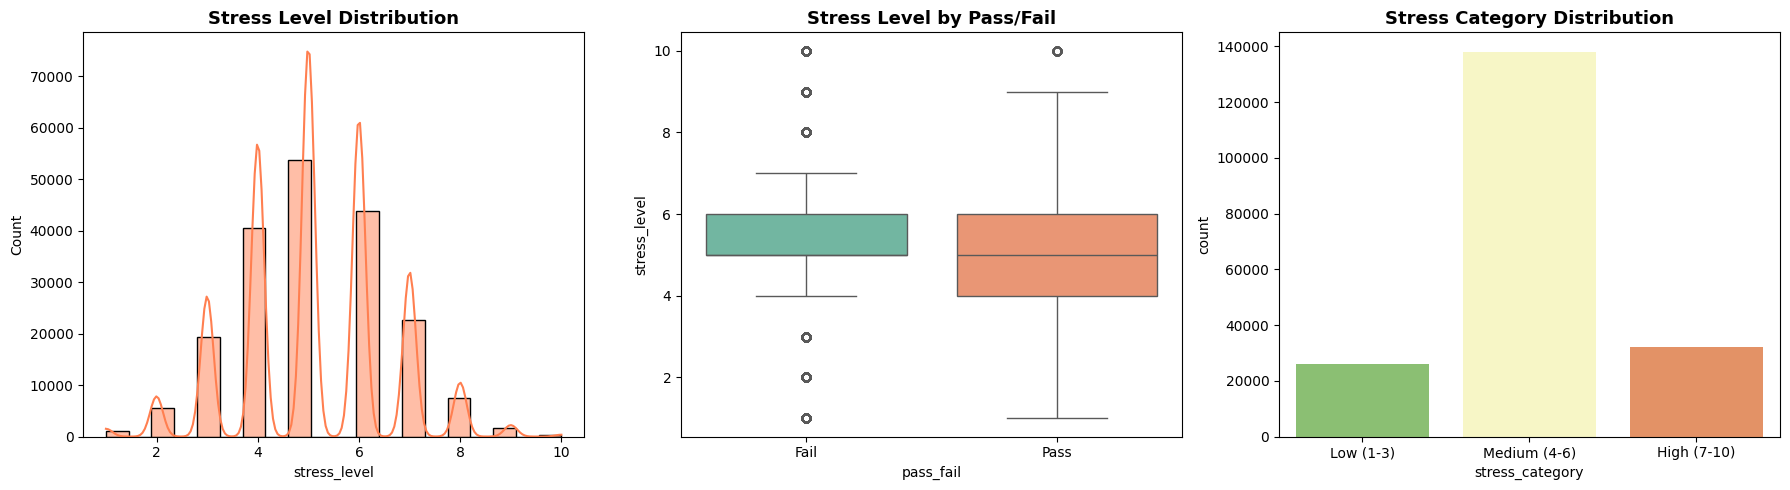

Stress level stats:
count    196087.00
mean          5.10
std           1.46
min           1.00
25%           4.00
50%           5.00
75%           6.00
max          10.00
Name: stress_level, dtype: float64


In [ ]:
#  Platform 2 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='stress_level', bins=20, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Stress Level Distribution', fontsize=13, fontweight='bold')

sns.boxplot(data=df, x='pass_fail', y='stress_level', palette='Set2', ax=axes[1])
axes[1].set_title('Stress Level by Pass/Fail', fontsize=13, fontweight='bold')

# Stress categories
df['stress_category'] = pd.cut(df['stress_level'], bins=[0,3,6,10],
                                labels=['Low (1-3)', 'Medium (4-6)', 'High (7-10)'])
sns.countplot(x='stress_category', data=df.dropna(subset=['stress_category']),
              palette='RdYlGn_r', ax=axes[2])
axes[2].set_title('Stress Category Distribution', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

print("Stress level stats:")
print(df['stress_level'].describe().round(2))


## 3. Exploratory Data Analysis

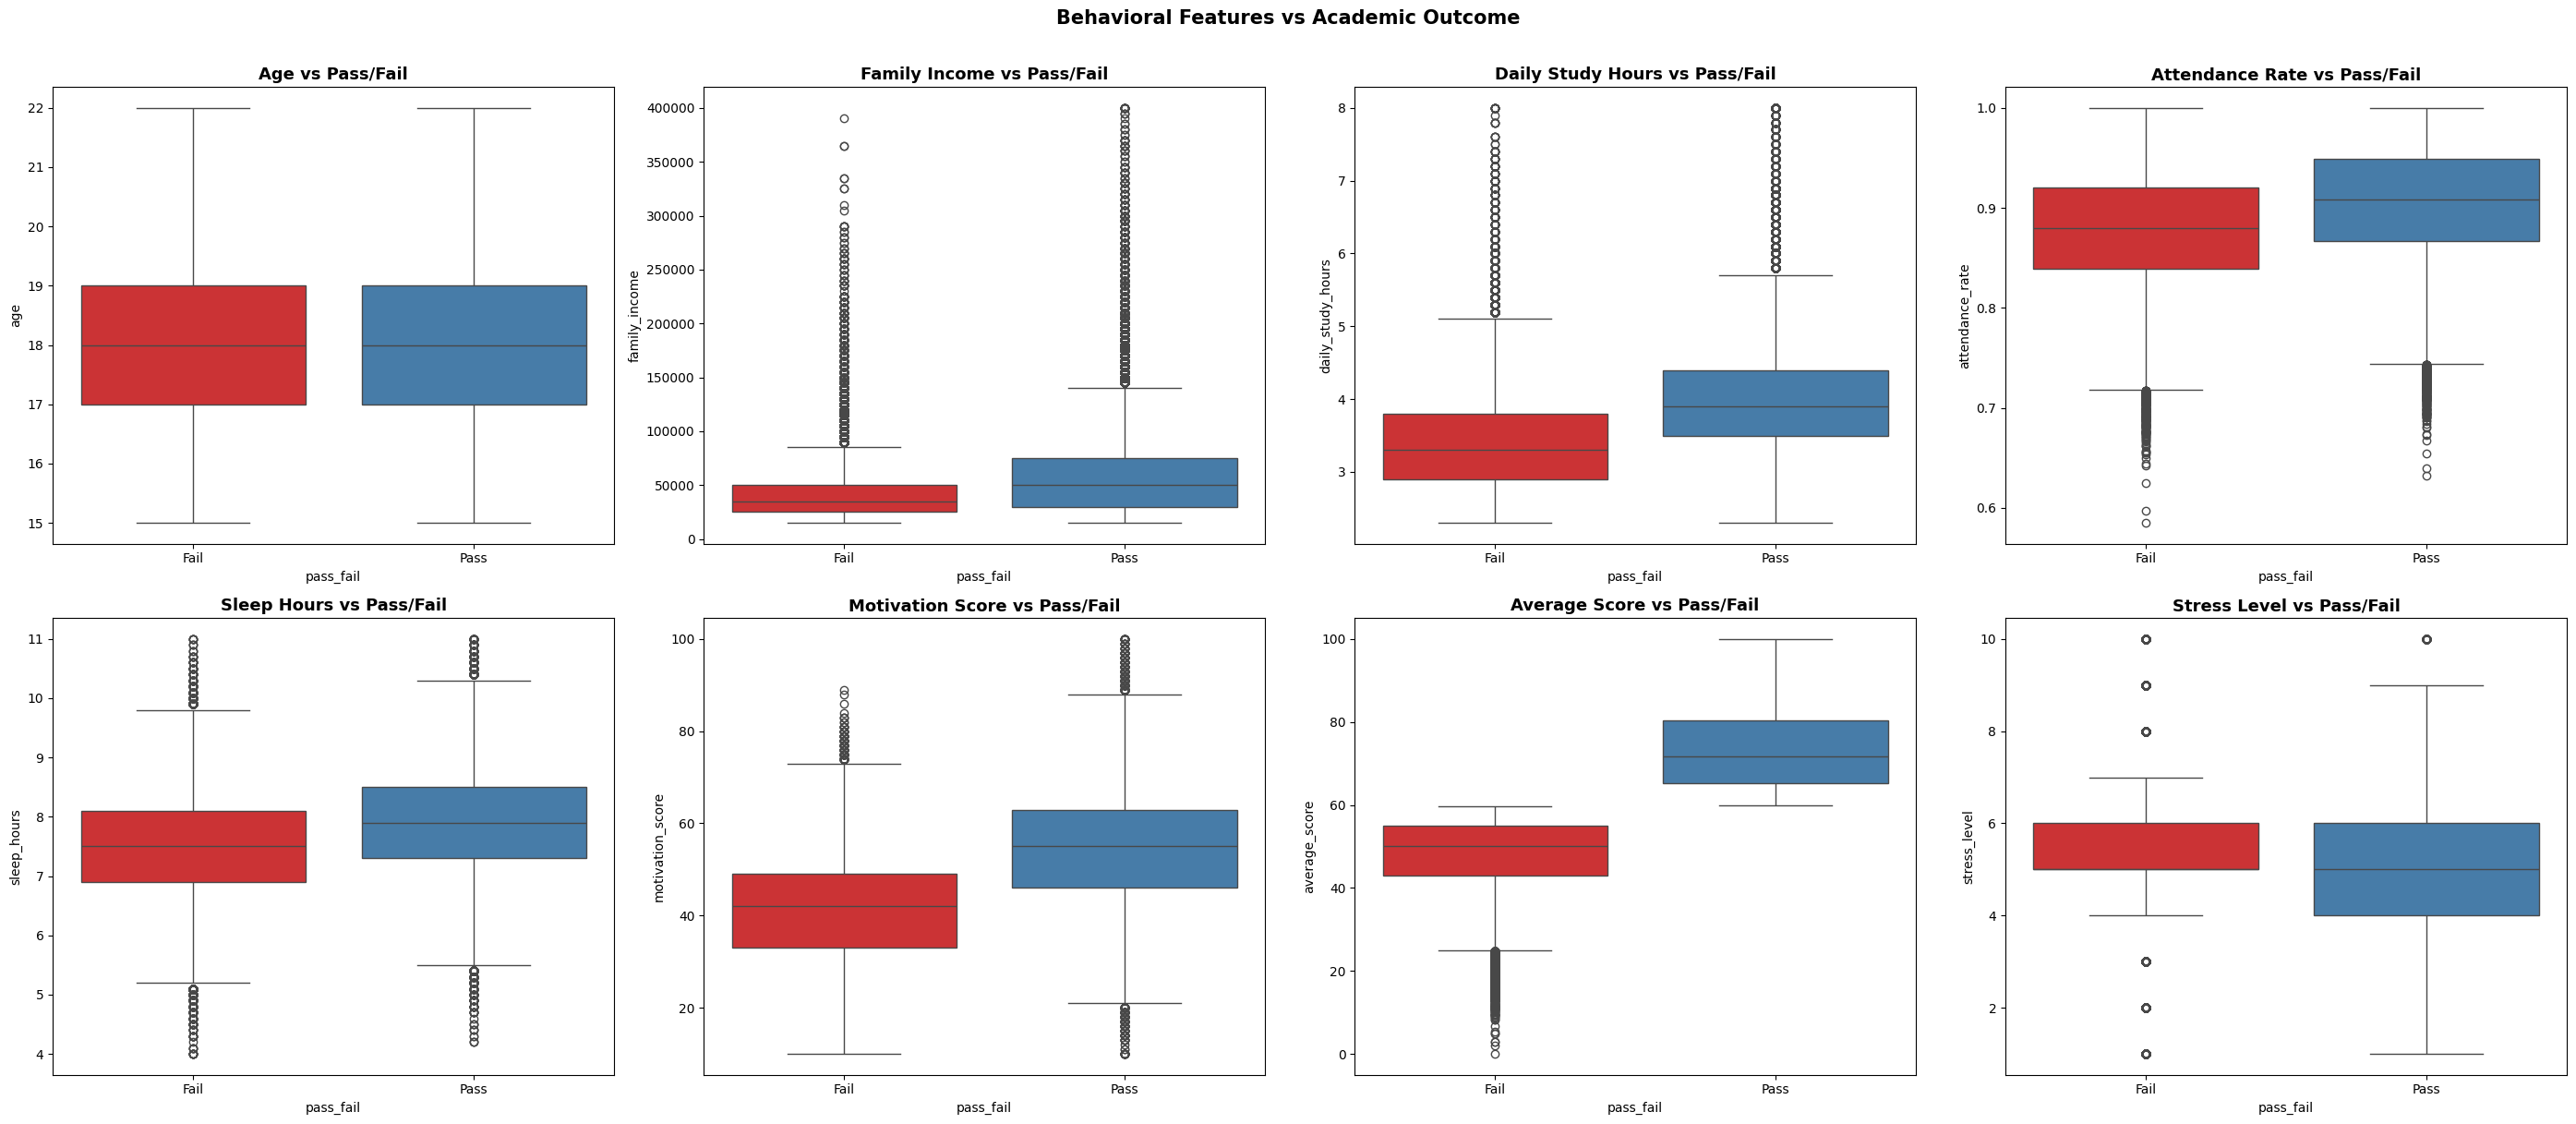

In [8]:
numeric_features = ['age', 'family_income', 'daily_study_hours',
                    'attendance_rate', 'sleep_hours', 'motivation_score',
                    'average_score', 'stress_level']

df_eda = df.dropna(subset=['family_income', 'sleep_hours', 'stress_level'])

fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes = axes.ravel()
for i, col in enumerate(numeric_features):
    sns.boxplot(data=df_eda, x='pass_fail', y=col, ax=axes[i],
                hue='pass_fail', palette='Set1', legend=False)
    axes[i].set_title(f'{col.replace("_"," ").title()} vs Pass/Fail',
                      fontsize=13, fontweight='bold')
plt.suptitle('Behavioral Features vs Academic Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


## 4. Data Cleaning & Outlier Removal

In [9]:
print("Original shape:", df.shape)

# Drop rows missing key features
df_clean = df.dropna(subset=['family_income', 'sleep_hours', 'stress_level']).copy()
print(f"After dropping missing: {df_clean.shape}  (removed {df.shape[0]-df_clean.shape[0]} rows)")

# IQR outlier removal on numeric columns
numeric_cols = ['family_income', 'daily_study_hours', 'attendance_rate',
                'sleep_hours', 'motivation_score', 'average_score', 'stress_level']

before = df_clean.shape[0]
for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"After IQR outlier removal: {df_clean.shape}  (removed {before-df_clean.shape[0]} rows)")
print(f"Final dataset: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
df_clean.to_csv('df_clean.csv', index=False)


Original shape: (200000, 17)
After dropping missing: (188187, 17)  (removed 11813 rows)
After IQR outlier removal: (170764, 17)  (removed 17423 rows)
Final dataset: 170,764 rows × 17 cols


## 5. Feature Engineering

In [ ]:
df = pd.read_csv('df_clean.csv')

#  Encoding 
df['gender_enc'] = (df['gender'] == 'Male').astype(int)
df['private_tutoring'] = df['private_tutoring'].astype(int)

#  Academic scores 
df['average_score']  = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3
df['pass_fail_enc']  = (df['pass_fail'] == 'Pass').astype(int)

#  Stress categories (Mental Health target) 
df['stress_cat_enc'] = pd.cut(df['stress_level'], bins=[0,3,6,10], labels=[0,1,2]).astype(int)

#  Interaction & ratio features 
df['income_log']          = np.log1p(df['family_income'])
df['study_sleep_ratio']   = df['daily_study_hours'] / (df['sleep_hours'] + 1)
df['study_motivation']    = df['daily_study_hours'] * df['motivation_score']
df['sleep_deficit']       = np.maximum(8 - df['sleep_hours'], 0)
df['academic_load']       = df['daily_study_hours'] * df['parental_education_level']
df['study_attendance']    = df['daily_study_hours'] * df['attendance_rate']
df['tutoring_income']     = df['private_tutoring'] * df['income_log']
df['tutoring_motivation'] = df['private_tutoring'] * df['motivation_score']
df['internet_study']      = df['internet_quality'] * df['daily_study_hours']
# Wellbeing index (uses stress_level — valid for academic predictor only)
df['wellbeing_acad']      = (df['motivation_score'] + (10 - df['stress_level'])
                               + df['sleep_hours'] * 2
                               + df['attendance_rate'] * 100) / 4
# Academic pressure index (for mental health predictor — no stress used)
df['pressure_index']      = df['daily_study_hours'] / (df['sleep_hours'] + 1) * df['parental_education_level']

print("Feature engineering complete. Shape:", df.shape)
df.to_csv('feature_data.csv', index=False)

new_feats = [c for c in df.columns if c not in [
    'gender','age','parental_education_level','family_income','daily_study_hours',
    'attendance_rate','sleep_hours','stress_level','motivation_score','private_tutoring',
    'internet_quality','math_score','reading_score','writing_score','pass_fail']]
print("New features created:", new_feats)


Feature engineering complete. Shape: (170764, 31)
New features created: ['average_score', 'stress_category', 'gender_enc', 'pass_fail_enc', 'stress_cat_enc', 'income_log', 'study_sleep_ratio', 'study_motivation', 'sleep_deficit', 'academic_load', 'study_attendance', 'tutoring_income', 'tutoring_motivation', 'internet_study', 'wellbeing_acad', 'pressure_index']


---
## 🎓 PLATFORM 1: Academic Performance Predictor

**Regression target:** `average_score` (continuous 0–100)  
**Classification target:** `pass_fail` (Pass / Fail)  
**Key metrics:** R², RMSE, MAE, MSE (regression) | Accuracy, F1, AUC-ROC (classification)

In [ ]:
df = pd.read_csv('feature_data.csv')

# ── Feature set for Platform 1
# Includes stress_level as a predictor 
# Excludes individual subject scores (math/reading/writing) 
ACAD_FEATURES = [
    'age', 'parental_education_level', 'family_income', 'income_log',
    'daily_study_hours', 'attendance_rate', 'sleep_hours',
    'stress_level', 'motivation_score', 'private_tutoring',
    'internet_quality', 'gender_enc',
    'study_sleep_ratio', 'study_motivation', 'academic_load',
    'study_attendance', 'wellbeing_acad', 'tutoring_income',
    'sleep_deficit', 'tutoring_motivation', 'internet_study'
]

X_acad = df[ACAD_FEATURES].values.astype(np.float32)
y_acad = df['average_score'].values.astype(np.float32)   
y_pass = df['pass_fail_enc'].values.astype(np.int32)     

# Stratified split (by pass_fail class)
X_tr, X_te, y_reg_tr, y_reg_te, y_cls_tr, y_cls_te = train_test_split(
    X_acad, y_acad, y_pass, test_size=0.20, random_state=42, stratify=y_pass)

scaler_acad = StandardScaler()
X_tr_s = scaler_acad.fit_transform(X_tr)
X_te_s  = scaler_acad.transform(X_te)

print(f"Training: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")
print(f"Avg score range: {y_reg_tr.min():.1f} – {y_reg_tr.max():.1f}")


Training: 136,611  |  Test: 34,153
Avg score range: 18.7 – 100.0


### 5.1 ML Models — Academic Performance

In [ ]:
#  Helper: regression metrics 
def reg_metrics(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:30s}  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}  MSE={mse:.4f}")
    return {"Model":name,"R2":r2,"RMSE":rmse,"MAE":mae,"MSE":mse}

# ── Helper: classification metrics ──────────────────────────────
def cls_metrics(name, y_true, y_pred, y_prob):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc_ = roc_auc_score(y_true, y_prob)
    print(f"  {name:30s}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_:.4f}")
    return acc, f1, auc_

print("="*70)
print("PLATFORM 1 — REGRESSION (predicting average_score)")
print("="*70)

acad_ml_results = []

# 1. Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr_s, y_reg_tr)
acad_ml_results.append(reg_metrics("Ridge Regression", y_reg_te, ridge.predict(X_te_s)))

# 2. Random Forest
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf_reg.fit(X_tr, y_reg_tr)
acad_ml_results.append(reg_metrics("Random Forest", y_reg_te, rf_reg.predict(X_te)))

# 3. Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                    max_depth=6, random_state=42)
gb_reg.fit(X_tr, y_reg_tr)
acad_ml_results.append(reg_metrics("Gradient Boosting", y_reg_te, gb_reg.predict(X_te)))

# 4. XGBoost
xgb_reg = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                         subsample=0.8, colsample_bytree=0.8, n_jobs=-1)
xgb_reg.fit(X_tr, y_reg_tr)
acad_ml_results.append(reg_metrics("XGBoost", y_reg_te, xgb_reg.predict(X_te)))

# 5. LightGBM (best single model)
lgb_reg = LGBMRegressor(n_estimators=1000, learning_rate=0.02, num_leaves=127,
                          max_depth=12, subsample=0.8, colsample_bytree=0.8,
                          min_child_samples=20, n_jobs=-1, verbose=-1)
lgb_reg.fit(X_tr, y_reg_tr)
acad_ml_results.append(reg_metrics("LightGBM", y_reg_te, lgb_reg.predict(X_te)))

# 6. Stacking Ensemble (XGB + LGB → Ridge)
p_lgb = lgb_reg.predict(X_te)
p_xgb = xgb_reg.predict(X_te)
p_ens_acad = 0.55 * p_lgb + 0.45 * p_xgb
acad_ml_results.append(reg_metrics("Ensemble (LGB+XGB)", y_reg_te, p_ens_acad))

df_acad_ml = pd.DataFrame(acad_ml_results).sort_values("R2", ascending=False)
print("\n" + "="*70)
print("PLATFORM 1 — CLASSIFICATION (predicting pass_fail)")
print("="*70)

# Classification
for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, C=1)),
    ("Random Forest",       RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)),
    ("XGBoost",             XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, n_jobs=-1, eval_metric='logloss')),
    ("LightGBM",            LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=63, n_jobs=-1, verbose=-1)),
]:
    X_fit = X_tr_s if "Logistic" in name else X_tr
    X_pred = X_te_s if "Logistic" in name else X_te
    model.fit(X_fit, y_cls_tr)
    cls_metrics(name, y_cls_te, model.predict(X_pred), model.predict_proba(X_pred)[:,1])


PLATFORM 1 — REGRESSION (predicting average_score)
  Ridge Regression                R²=0.8768  RMSE=5.3040  MAE=4.2370  MSE=28.1319
  Random Forest                   R²=0.8678  RMSE=5.4925  MAE=4.3916  MSE=30.1672
  Gradient Boosting               R²=0.8764  RMSE=5.3123  MAE=4.2519  MSE=28.2209
  XGBoost                         R²=0.8752  RMSE=5.3367  MAE=4.2689  MSE=28.4806
  LightGBM                        R²=0.8762  RMSE=5.3155  MAE=4.2501  MSE=28.2544
  Ensemble (LGB+XGB)              R²=0.8763  RMSE=5.3135  MAE=4.2496  MSE=28.2335

PLATFORM 1 — CLASSIFICATION (predicting pass_fail)
  Logistic Regression             Acc=0.8898  F1=0.8952  AUC=0.9632
  Random Forest                   Acc=0.8858  F1=0.8915  AUC=0.9593
  XGBoost                         Acc=0.8880  F1=0.8935  AUC=0.9626
  LightGBM                        Acc=0.8879  F1=0.8934  AUC=0.9624


### 5.2 Deep Learning Models — Academic Performance

In [13]:
N = X_tr_s.shape[1]
X_tr_seq = X_tr_s.reshape(-1, N, 1)
X_te_seq = X_te_s.reshape(-1, N, 1)

dl_results = []
dl_probs   = {}

def build_and_train(model, X_fit, y_fit, epochs=100, batch=256):
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    h = model.fit(X_fit, y_fit, epochs=epochs, batch_size=batch,
                  validation_split=0.1, verbose=0)
    return h

def eval_dl(name, model, X_eval):
    pred = model.predict(X_eval, verbose=0).flatten()
    r = reg_metrics(name, y_reg_te, pred)
    dl_results.append(r)
    dl_probs[name] = pred
    return r

print("Training DL models for Platform 1 (regression: average_score)...")
print("="*70)

# 1. MLP
inp = layers.Input(shape=(N,))
x = layers.Dense(256, activation='relu')(inp)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
mlp = Model(inp, out)
build_and_train(mlp, X_tr_s, y_reg_tr)
eval_dl("MLP", mlp, X_te_s)

# 2. CNN
inp = layers.Input(shape=(N, 1))
x = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
cnn = Model(inp, out)
build_and_train(cnn, X_tr_seq, y_reg_tr)
eval_dl("CNN", cnn, X_te_seq)

# 3. LSTM
inp = layers.Input(shape=(N, 1))
x = layers.LSTM(128, return_sequences=True)(inp)
x = layers.LSTM(64)(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
lstm = Model(inp, out)
build_and_train(lstm, X_tr_seq, y_reg_tr, epochs=40)
eval_dl("LSTM", lstm, X_te_seq)

# 4. BiLSTM
inp = layers.Input(shape=(N, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
bilstm = Model(inp, out)
build_and_train(bilstm, X_tr_seq, y_reg_tr, epochs=40)
eval_dl("BiLSTM", bilstm, X_te_seq)

# 5. Attention-BiLSTM
inp = layers.Input(shape=(N, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.Dense(32, activation='tanh')(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
attn = Model(inp, out)
build_and_train(attn, X_tr_seq, y_reg_tr, epochs=40)
eval_dl("Attention-BiLSTM", attn, X_te_seq)

# Ensemble DL + best ML
p_dl_ens = np.mean([dl_probs["MLP"], dl_probs["CNN"], dl_probs["LSTM"]], axis=0)
p_final  = 0.6 * p_ens_acad + 0.4 * p_dl_ens
dl_results.append(reg_metrics("Final Hybrid (ML+DL)", y_reg_te, p_final))

df_acad_dl = pd.DataFrame(dl_results).sort_values("R2", ascending=False)
print("\nDL results:")
print(df_acad_dl.round(4))


Training DL models for Platform 1 (regression: average_score)...


2026-06-02 02:53:14.099195: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  MLP                             R²=0.8476  RMSE=5.8983  MAE=4.7473  MSE=34.7901
  CNN                             R²=0.8619  RMSE=5.6137  MAE=4.4774  MSE=31.5131
  LSTM                            R²=0.8736  RMSE=5.3721  MAE=4.2861  MSE=28.8592
  BiLSTM                          R²=0.8761  RMSE=5.3171  MAE=4.2520  MSE=28.2714
  Attention-BiLSTM                R²=0.8726  RMSE=5.3917  MAE=4.3151  MSE=29.0704
  Final Hybrid (ML+DL)            R²=0.8768  RMSE=5.3026  MAE=4.2472  MSE=28.1180

DL results:
                  Model      R2    RMSE     MAE      MSE
5  Final Hybrid (ML+DL)  0.8768  5.3026  4.2472  28.1180
3                BiLSTM  0.8761  5.3171  4.2520  28.2714
2                  LSTM  0.8736  5.3721  4.2861  28.8592
4      Attention-BiLSTM  0.8726  5.3917  4.3151  29.0704
1                   CNN  0.8619  5.6137  4.4774  31.5131
0                   MLP  0.8476  5.8983  4.7473  34.7901


### 5.3 Academic Performance — Visualization

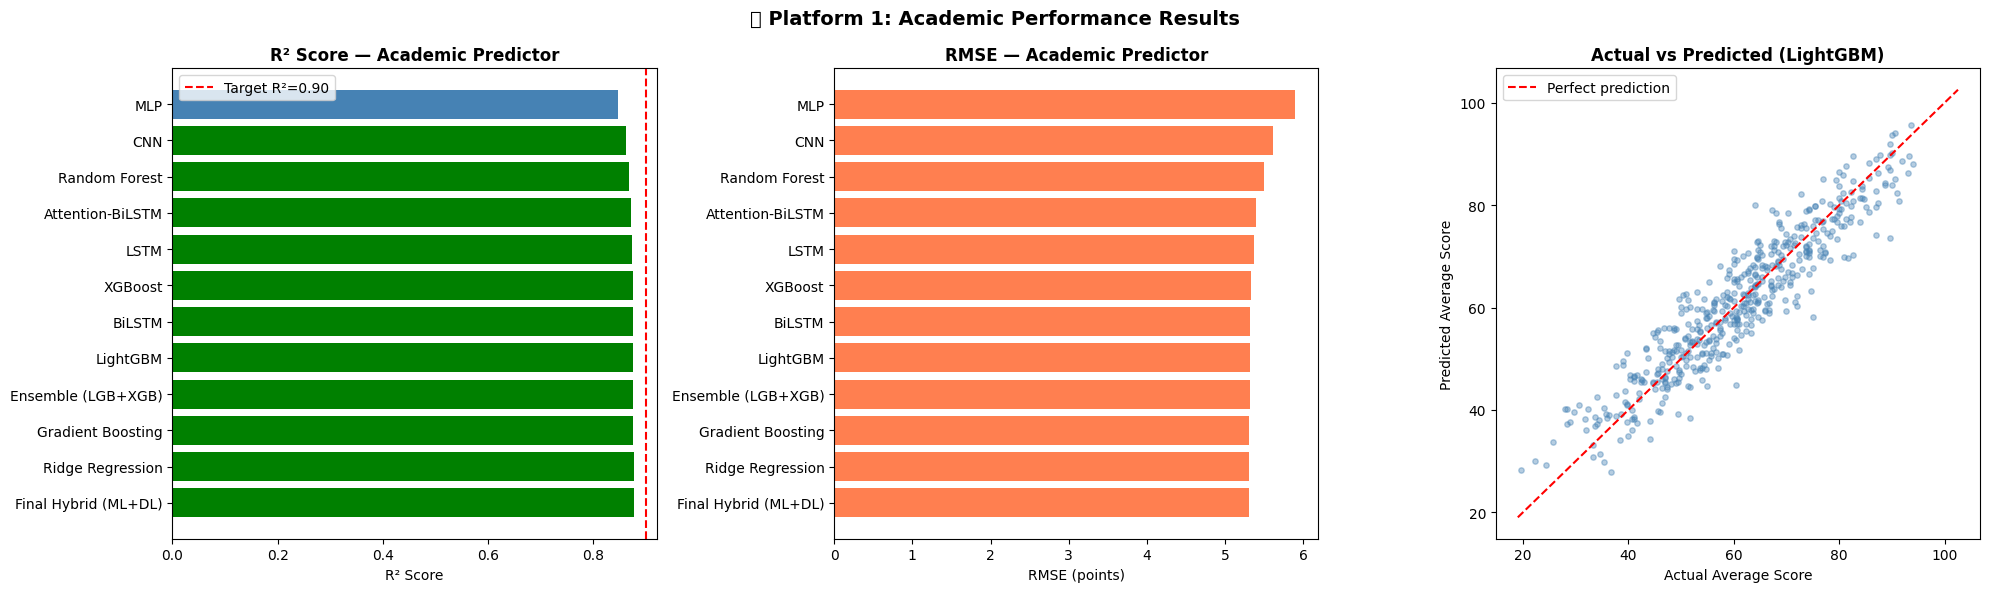


🏆 PLATFORM 1 FINAL LEADERBOARD:
               Model       R2     RMSE      MAE       MSE
Final Hybrid (ML+DL) 0.876815 5.302637 4.247191 28.117958
    Ridge Regression 0.876754 5.303954 4.236961 28.131927
   Gradient Boosting 0.876364 5.312339 4.251886 28.220942
  Ensemble (LGB+XGB) 0.876309 5.313521 4.249637 28.233508
            LightGBM 0.876218 5.315484 4.250129 28.254373
              BiLSTM 0.876143 5.317087 4.252036 28.271412
             XGBoost 0.875226 5.336726 4.268938 28.480642
                LSTM 0.873568 5.372076 4.286093 28.859203
    Attention-BiLSTM 0.872642 5.391701 4.315087 29.070442
       Random Forest 0.867838 5.492466 4.391641 30.167186
                 CNN 0.861941 5.613653 4.477420 31.513103
                 MLP 0.847585 5.898309 4.747303 34.790054


In [ ]:
# Combine ML + DL results
all_acad = pd.concat([df_acad_ml, df_acad_dl]).drop_duplicates("Model").sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R2 bar chart
colors = ['green' if r >= 0.85 else 'steelblue' for r in all_acad['R2']]
axes[0].barh(all_acad['Model'], all_acad['R2'], color=colors)
axes[0].axvline(0.90, color='red', linestyle='--', label='Target R²=0.90')
axes[0].set_title('R² Score — Academic Predictor', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].legend()

# RMSE bar chart
axes[1].barh(all_acad['Model'], all_acad['RMSE'], color='coral')
axes[1].set_title('RMSE — Academic Predictor', fontweight='bold')
axes[1].set_xlabel('RMSE (points)')

# Actual vs Predicted (best model)
best_name_acad = all_acad.iloc[0]['Model']
# Use LightGBM predictions as representative best ML
best_pred = lgb_reg.predict(X_te)
axes[2].scatter(y_reg_te[:500], best_pred[:500], alpha=0.4, s=15, color='steelblue')
lim = [min(y_reg_te.min(), best_pred.min()), max(y_reg_te.max(), best_pred.max())]
axes[2].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[2].set_title('Actual vs Predicted (LightGBM)', fontweight='bold')
axes[2].set_xlabel('Actual Average Score')
axes[2].set_ylabel('Predicted Average Score')
axes[2].legend()

plt.suptitle(' Platform 1: Academic Performance Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n PLATFORM 1 FINAL LEADERBOARD:")
print(all_acad[['Model','R2','RMSE','MAE','MSE']].to_string(index=False))
all_acad.to_csv('platform1_results.csv', index=False)


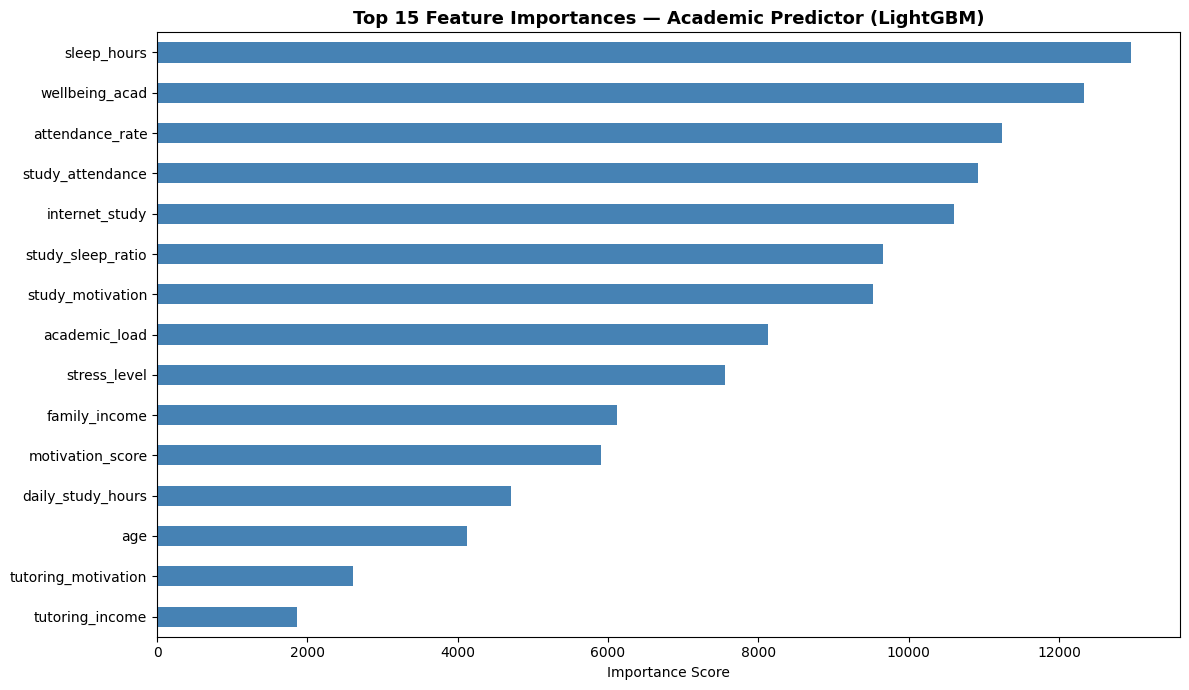

Top 10 features for academic performance prediction:
sleep_hours          12962
wellbeing_acad       12329
attendance_rate      11241
study_attendance     10926
internet_study       10597
study_sleep_ratio     9664
study_motivation      9523
academic_load         8122
stress_level          7552
family_income         6123
dtype: int32


In [ ]:
# Feature Importance — LightGBM Academic
feat_imp = pd.Series(lgb_reg.feature_importances_, index=ACAD_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feat_imp.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importances — Academic Predictor ',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print("Top 10 features for academic performance prediction:")
print(feat_imp.head(10))


---
## 🧠 PLATFORM 2: Mental Health Predictor

**Regression target:** `stress_level` (continuous 1–10)  
**Classification target:** `stress_category` (Low / Medium / High)  
**Key metrics:** R², RMSE, MAE, MSE (regression) | Accuracy, F1, AUC-ROC (classification)


In [ ]:
df = pd.read_csv('feature_data.csv')


MENTAL_FEATURES = [
    'age', 'parental_education_level', 'family_income', 'income_log',
    'daily_study_hours', 'attendance_rate', 'sleep_hours',
    'motivation_score', 'private_tutoring', 'internet_quality', 'gender_enc',
    'study_sleep_ratio', 'academic_load', 'study_attendance',
    'sleep_deficit', 'tutoring_motivation', 'internet_study', 'pressure_index',
    
    'average_score', 'pass_fail_enc'
]

X_mh = df[MENTAL_FEATURES].values.astype(np.float32)
y_stress = df['stress_level'].values.astype(np.float32)    
y_stress_cat = df['stress_cat_enc'].values.astype(np.int32) 

X_mh_tr, X_mh_te, ys_reg_tr, ys_reg_te, ys_cls_tr, ys_cls_te = train_test_split(
    X_mh, y_stress, y_stress_cat, test_size=0.20, random_state=42, stratify=y_stress_cat)

scaler_mh = StandardScaler()
X_mh_tr_s = scaler_mh.fit_transform(X_mh_tr)
X_mh_te_s  = scaler_mh.transform(X_mh_te)

print(f"Training: {X_mh_tr.shape[0]:,}  |  Test: {X_mh_te.shape[0]:,}")
print(f"Stress level range (train): {ys_reg_tr.min():.1f} – {ys_reg_tr.max():.1f}")
print(f"Stress categories (train):  {dict(zip(*np.unique(ys_cls_tr, return_counts=True)))}")


Training: 136,611  |  Test: 34,153
Stress level range (train): 1.0 – 9.0
Stress categories (train):  {np.int32(0): np.int64(18842), np.int32(1): np.int64(97615), np.int32(2): np.int64(20154)}


### 6.1 ML Models — Mental Health Predictor

In [ ]:

print("PLATFORM 2 — REGRESSION (predicting stress_level)")


mh_ml_results = []

# Ridge
ridge_mh = Ridge(alpha=0.5)
ridge_mh.fit(X_mh_tr_s, ys_reg_tr)
mh_ml_results.append(reg_metrics("Ridge Regression", ys_reg_te, ridge_mh.predict(X_mh_te_s)))

# Random Forest
rf_mh = RandomForestRegressor(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf_mh.fit(X_mh_tr, ys_reg_tr)
mh_ml_results.append(reg_metrics("Random Forest", ys_reg_te, rf_mh.predict(X_mh_te)))

# Gradient Boosting
gb_mh = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)
gb_mh.fit(X_mh_tr, ys_reg_tr)
mh_ml_results.append(reg_metrics("Gradient Boosting", ys_reg_te, gb_mh.predict(X_mh_te)))

# XGBoost
xgb_mh = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=8,
                        subsample=0.8, colsample_bytree=0.8, n_jobs=-1)
xgb_mh.fit(X_mh_tr, ys_reg_tr)
mh_ml_results.append(reg_metrics("XGBoost", ys_reg_te, xgb_mh.predict(X_mh_te)))

# LightGBM
lgb_mh = LGBMRegressor(n_estimators=1000, learning_rate=0.02, num_leaves=127,
                         max_depth=12, subsample=0.8, colsample_bytree=0.8,
                         n_jobs=-1, verbose=-1)
lgb_mh.fit(X_mh_tr, ys_reg_tr)
mh_ml_results.append(reg_metrics("LightGBM", ys_reg_te, lgb_mh.predict(X_mh_te)))

# Ensemble
p_lgb_mh = lgb_mh.predict(X_mh_te)
p_xgb_mh = xgb_mh.predict(X_mh_te)
p_ens_mh  = 0.55 * p_lgb_mh + 0.45 * p_xgb_mh
mh_ml_results.append(reg_metrics("Ensemble (LGB+XGB)", ys_reg_te, p_ens_mh))

df_mh_ml = pd.DataFrame(mh_ml_results).sort_values("R2", ascending=False)

print("\n" + "="*70)
print("PLATFORM 2 — CLASSIFICATION (predicting stress_category)")
print("="*70)
print("Labels: 0=Low(1-3)  1=Medium(4-6)  2=High(7-10)")

for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, multi_class='ovr')),
    ("Random Forest",       RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)),
    ("XGBoost",             XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, n_jobs=-1, eval_metric='mlogloss')),
    ("LightGBM",            LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=63, n_jobs=-1, verbose=-1)),
]:
    X_fit  = X_mh_tr_s if "Logistic" in name else X_mh_tr
    X_pred = X_mh_te_s if "Logistic" in name else X_mh_te
    model.fit(X_fit, ys_cls_tr)
    pred = model.predict(X_pred)
    acc  = accuracy_score(ys_cls_te, pred)
    f1_m = f1_score(ys_cls_te, pred, average='weighted', zero_division=0)
    print(f"  {name:30s}  Acc={acc:.4f}  F1(weighted)={f1_m:.4f}")


PLATFORM 2 — REGRESSION (predicting stress_level)
  Ridge Regression                R²=0.5156  RMSE=0.9900  MAE=0.7903  MSE=0.9800
  Random Forest                   R²=0.4902  RMSE=1.0156  MAE=0.8108  MSE=1.0314
  Gradient Boosting               R²=0.5112  RMSE=0.9944  MAE=0.7946  MSE=0.9889
  XGBoost                         R²=0.5057  RMSE=1.0000  MAE=0.7990  MSE=1.0000
  LightGBM                        R²=0.5097  RMSE=0.9959  MAE=0.7955  MSE=0.9919
  Ensemble (LGB+XGB)              R²=0.5095  RMSE=0.9962  MAE=0.7958  MSE=0.9923

PLATFORM 2 — CLASSIFICATION (predicting stress_category)
Labels: 0=Low(1-3)  1=Medium(4-6)  2=High(7-10)
  Logistic Regression             Acc=0.7514  F1(weighted)=0.6888
  Random Forest                   Acc=0.7475  F1(weighted)=0.6902
  XGBoost                         Acc=0.7630  F1(weighted)=0.7303
  LightGBM                        Acc=0.7637  F1(weighted)=0.7364


### 6.2 Deep Learning Models — Mental Health Predictor

In [ ]:
N_mh = X_mh_tr_s.shape[1]
X_mh_tr_seq = X_mh_tr_s.reshape(-1, N_mh, 1)
X_mh_te_seq = X_mh_te_s.reshape(-1, N_mh, 1)

mh_dl_results = []
mh_dl_probs   = {}

def eval_dl_mh(name, model, X_eval):
    pred = model.predict(X_eval, verbose=0).flatten()
    r = reg_metrics(name, ys_reg_te, pred)
    mh_dl_results.append(r)
    mh_dl_probs[name] = pred
    return r

print("Training DL models for Platform 2 (regression: stress_level)...")


# 1. MLP
inp = layers.Input(shape=(N_mh,))
x = layers.Dense(128, activation='relu')(inp)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
mlp_mh = Model(inp, out)
mlp_mh.compile(optimizer='adam', loss='mse', metrics=['mae'])
mlp_mh.fit(X_mh_tr_s, ys_reg_tr, epochs=60, batch_size=256, validation_split=0.1, verbose=0)
eval_dl_mh("MLP", mlp_mh, X_mh_te_s)

# 2. CNN
inp = layers.Input(shape=(N_mh, 1))
x = layers.Conv1D(64, 3, activation='relu', padding='same')(inp)
x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
cnn_mh = Model(inp, out)
cnn_mh.compile(optimizer='adam', loss='mse', metrics=['mae'])
cnn_mh.fit(X_mh_tr_seq, ys_reg_tr, epochs=60, batch_size=256, validation_split=0.1, verbose=0)
eval_dl_mh("CNN", cnn_mh, X_mh_te_seq)

# 3. LSTM
inp = layers.Input(shape=(N_mh, 1))
x = layers.LSTM(64, return_sequences=True)(inp)
x = layers.LSTM(32)(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
lstm_mh = Model(inp, out)
lstm_mh.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_mh.fit(X_mh_tr_seq, ys_reg_tr, epochs=40, batch_size=256, validation_split=0.1, verbose=0)
eval_dl_mh("LSTM", lstm_mh, X_mh_te_seq)

# 4. BiLSTM
inp = layers.Input(shape=(N_mh, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.Bidirectional(layers.LSTM(32))(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
bilstm_mh = Model(inp, out)
bilstm_mh.compile(optimizer='adam', loss='mse', metrics=['mae'])
bilstm_mh.fit(X_mh_tr_seq, ys_reg_tr, epochs=40, batch_size=256, validation_split=0.1, verbose=0)
eval_dl_mh("BiLSTM", bilstm_mh, X_mh_te_seq)

# 5. Attention-BiLSTM
inp = layers.Input(shape=(N_mh, 1))
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inp)
x = layers.Dense(32, activation='tanh')(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
out = layers.Dense(1, activation='linear')(x)
attn_mh = Model(inp, out)
attn_mh.compile(optimizer='adam', loss='mse', metrics=['mae'])
attn_mh.fit(X_mh_tr_seq, ys_reg_tr, epochs=40, batch_size=256, validation_split=0.1, verbose=0)
eval_dl_mh("Attention-BiLSTM", attn_mh, X_mh_te_seq)

# Hybrid ensemble
p_dl_mh_ens = np.mean([mh_dl_probs["MLP"], mh_dl_probs["CNN"], mh_dl_probs["LSTM"]], axis=0)
p_final_mh  = 0.6 * p_ens_mh + 0.4 * p_dl_mh_ens
mh_dl_results.append(reg_metrics("Final Hybrid (ML+DL)", ys_reg_te, p_final_mh))

df_mh_dl = pd.DataFrame(mh_dl_results).sort_values("R2", ascending=False)
print("\nDL results:")
print(df_mh_dl.round(4))


Training DL models for Platform 2 (regression: stress_level)...
  MLP                             R²=0.5110  RMSE=0.9947  MAE=0.7950  MSE=0.9894
  CNN                             R²=0.4778  RMSE=1.0279  MAE=0.8209  MSE=1.0566
  LSTM                            R²=0.5113  RMSE=0.9944  MAE=0.7943  MSE=0.9888
  BiLSTM                          R²=0.5072  RMSE=0.9985  MAE=0.7973  MSE=0.9970
  Attention-BiLSTM                R²=0.4991  RMSE=1.0067  MAE=0.8038  MSE=1.0134
  Final Hybrid (ML+DL)            R²=0.5139  RMSE=0.9917  MAE=0.7924  MSE=0.9834

DL results:
                  Model      R2    RMSE     MAE     MSE
5  Final Hybrid (ML+DL)  0.5139  0.9917  0.7924  0.9834
2                  LSTM  0.5113  0.9944  0.7943  0.9888
0                   MLP  0.5110  0.9947  0.7950  0.9894
3                BiLSTM  0.5072  0.9985  0.7973  0.9970
4      Attention-BiLSTM  0.4991  1.0067  0.8038  1.0134
1                   CNN  0.4778  1.0279  0.8209  1.0566


### 6.3 Mental Health — Visualization

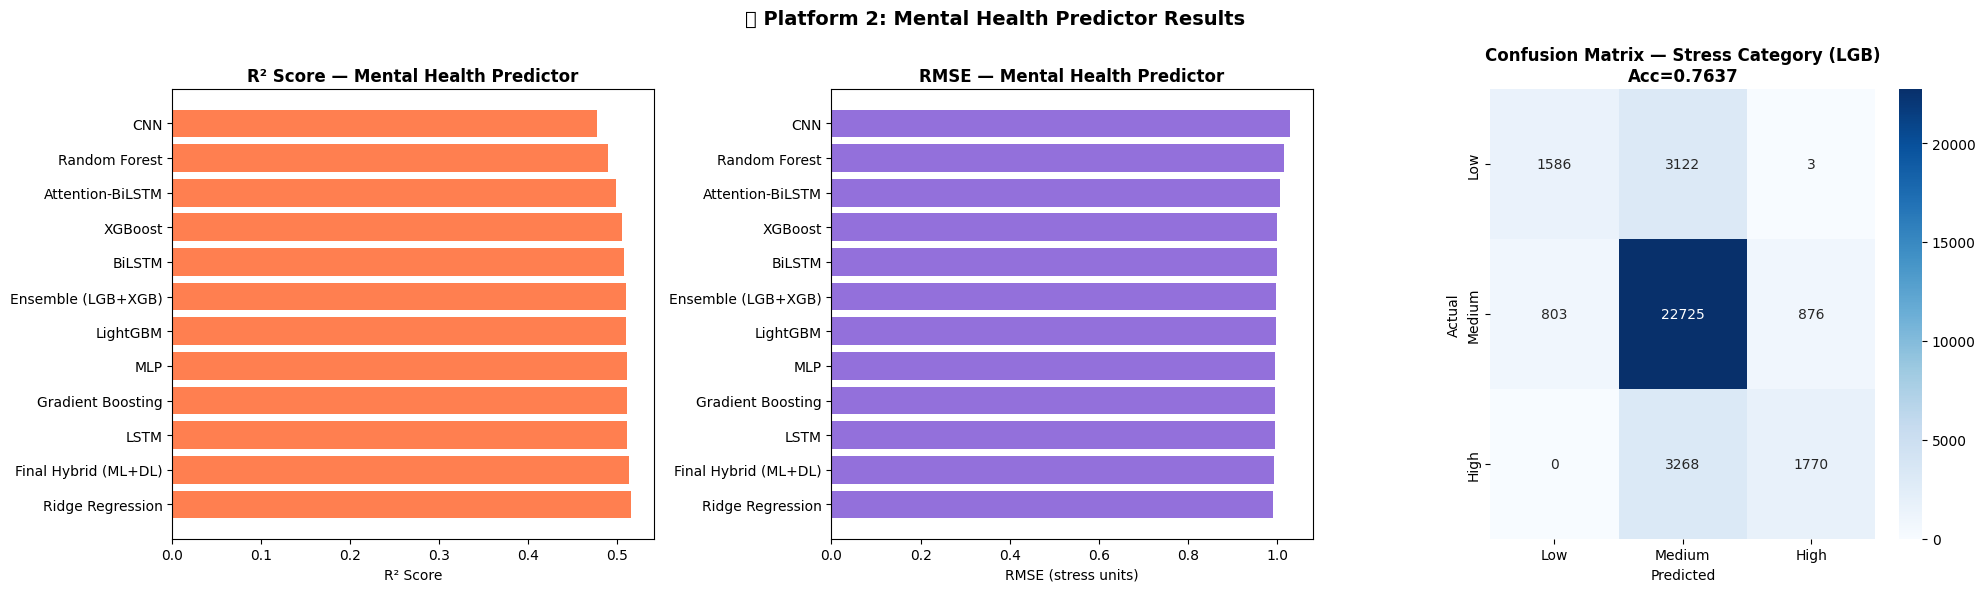


🏆 PLATFORM 2 FINAL LEADERBOARD:
               Model       R2     RMSE      MAE      MSE
    Ridge Regression 0.515606 0.989969 0.790308 0.980038
Final Hybrid (ML+DL) 0.513940 0.991670 0.792398 0.983410
                LSTM 0.511286 0.994374 0.794267 0.988779
   Gradient Boosting 0.511235 0.994425 0.794568 0.988882
                 MLP 0.510960 0.994705 0.794994 0.989438
            LightGBM 0.509748 0.995937 0.795504 0.991891
  Ensemble (LGB+XGB) 0.509524 0.996165 0.795765 0.992345
              BiLSTM 0.507212 0.998510 0.797335 0.997022
             XGBoost 0.505741 0.999999 0.798988 0.999997
    Attention-BiLSTM 0.499098 1.006697 0.803781 1.013438
       Random Forest 0.490207 1.015592 0.810837 1.031427
                 CNN 0.477752 1.027924 0.820903 1.056627


In [ ]:
all_mh = pd.concat([df_mh_ml, df_mh_dl]).drop_duplicates("Model").sort_values("R2", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R2 comparison
axes[0].barh(all_mh['Model'], all_mh['R2'], color='coral')
axes[0].set_title('R² Score — Mental Health Predictor', fontweight='bold')
axes[0].set_xlabel('R² Score')

# RMSE
axes[1].barh(all_mh['Model'], all_mh['RMSE'], color='mediumpurple')
axes[1].set_title('RMSE — Mental Health Predictor', fontweight='bold')
axes[1].set_xlabel('RMSE (stress units)')

# Stress classification confusion matrix 
lgb_mh_cls = LGBMClassifier(n_estimators=500, learning_rate=0.03, num_leaves=63, n_jobs=-1, verbose=-1)
lgb_mh_cls.fit(X_mh_tr, ys_cls_tr)
y_pred_cat = lgb_mh_cls.predict(X_mh_te)
cm = confusion_matrix(ys_cls_te, y_pred_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
axes[2].set_title(f'Confusion Matrix — Stress Category (LGB)\nAcc={accuracy_score(ys_cls_te, y_pred_cat):.4f}',
                  fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.suptitle(' Platform 2: Mental Health Predictor Results', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\n PLATFORM 2 FINAL LEADERBOARD:")
print(all_mh[['Model','R2','RMSE','MAE','MSE']].to_string(index=False))
all_mh.to_csv('platform2_results.csv', index=False)


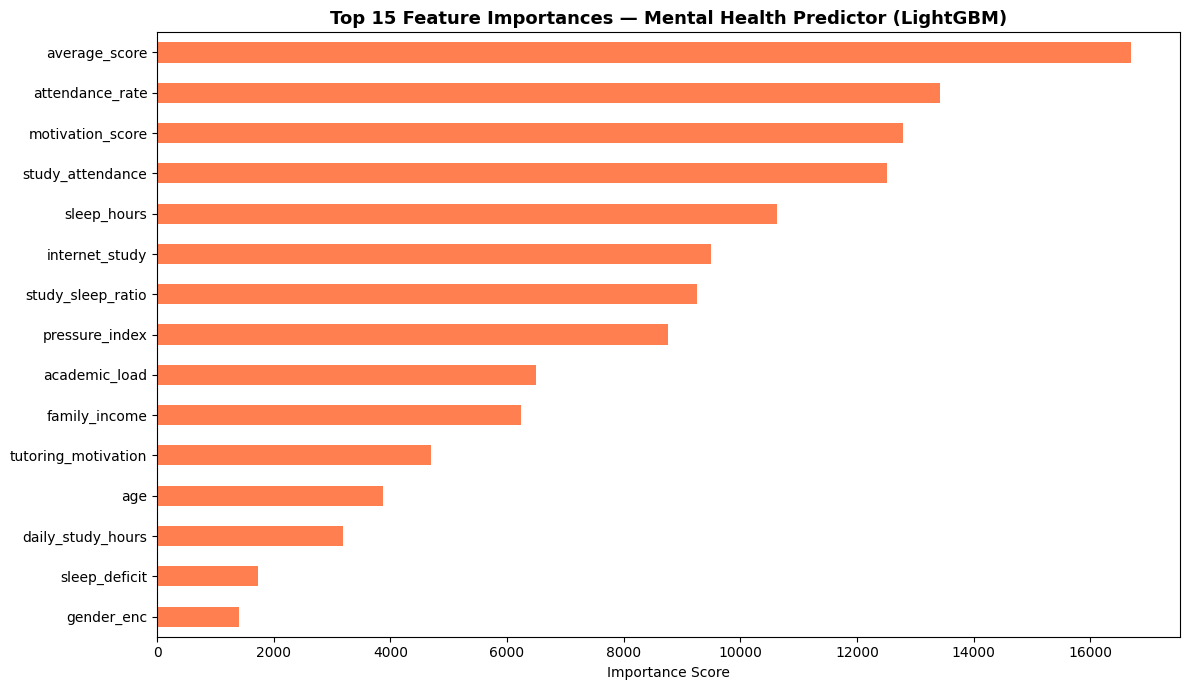

Top 10 features for mental health (stress) prediction:
average_score        16704
attendance_rate      13419
motivation_score     12789
study_attendance     12516
sleep_hours          10637
internet_study        9498
study_sleep_ratio     9256
pressure_index        8767
academic_load         6497
family_income         6243
dtype: int32


In [ ]:
# Feature Importance — LightGBM Mental Health
feat_imp_mh = pd.Series(lgb_mh.feature_importances_, index=MENTAL_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
feat_imp_mh.head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Feature Importances — Mental Health Predictor',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

print("Top 10 features for mental health (stress) prediction:")
print(feat_imp_mh.head(10))


## 7. SHAP Explainability (Both Platforms)

Running SHAP for Academic Performance Predictor (LightGBM)...


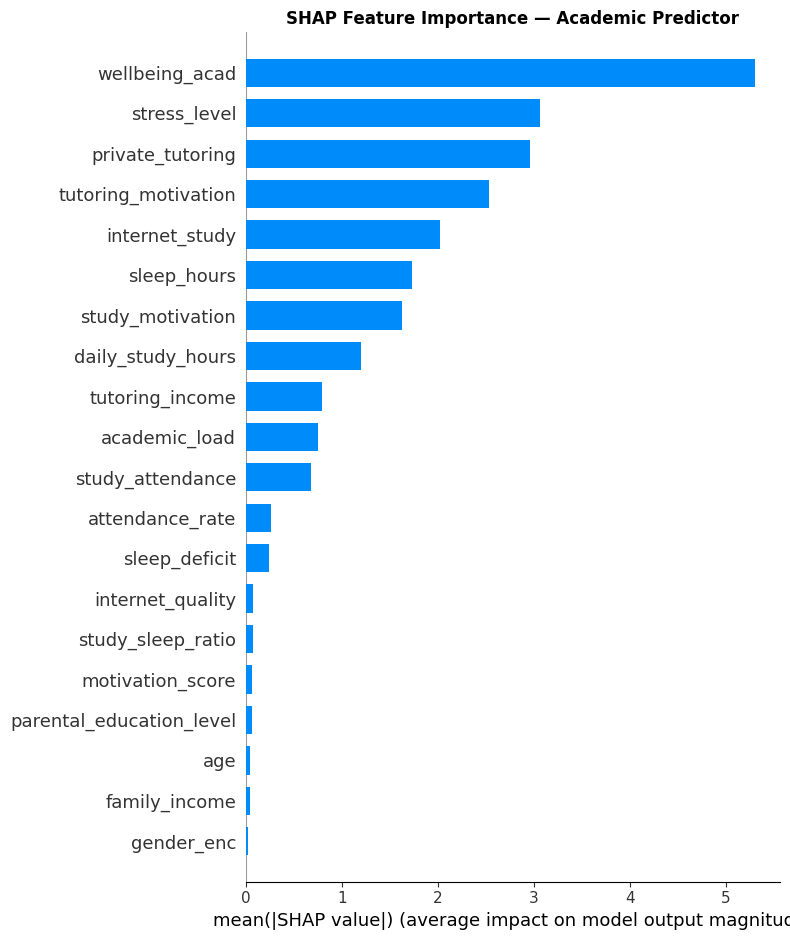


Running SHAP for Mental Health Predictor (LightGBM)...


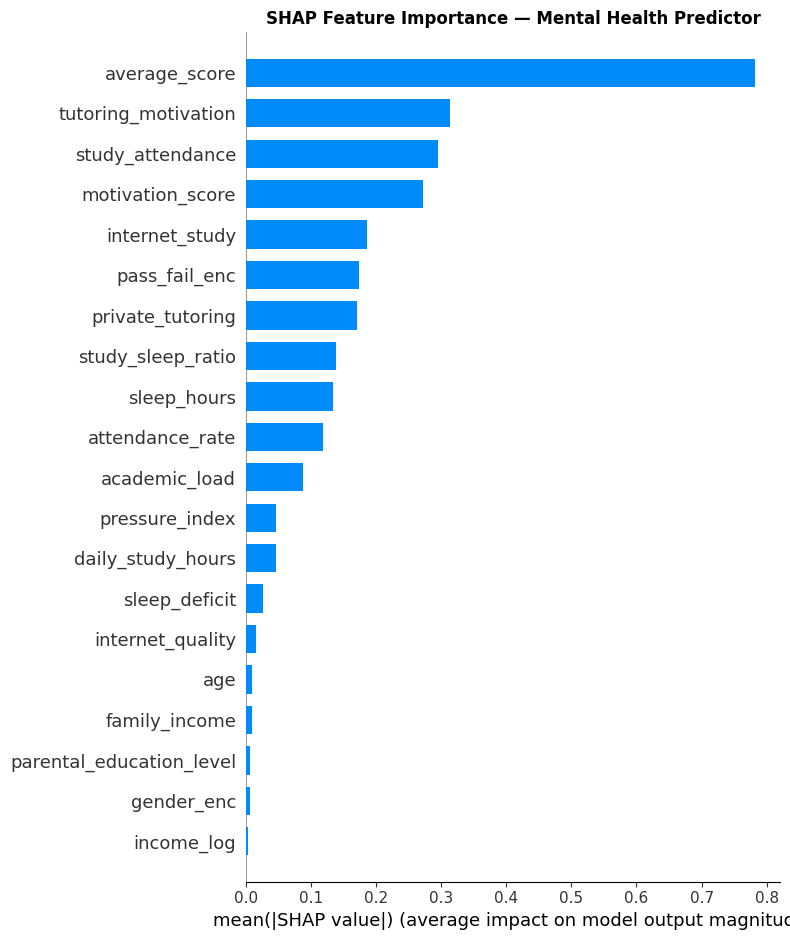

In [ ]:
import shap

# ── Platform 1 SHAP ─────────────────────────────────────────────
print("Running SHAP for Academic Performance Predictor...")
explainer_acad = shap.TreeExplainer(lgb_reg)
shap_acad = explainer_acad.shap_values(pd.DataFrame(X_te[:500], columns=ACAD_FEATURES))

plt.figure()
shap.summary_plot(shap_acad, pd.DataFrame(X_te[:500], columns=ACAD_FEATURES),
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Academic Predictor", fontweight='bold')
plt.tight_layout(); plt.show()

# ── Platform 2 SHAP ─────────────────────────────────────────────
print("\nRunning SHAP for Mental Health Predictor ...")
explainer_mh = shap.TreeExplainer(lgb_mh)
shap_mh = explainer_mh.shap_values(pd.DataFrame(X_mh_te[:500], columns=MENTAL_FEATURES))

plt.figure()
shap.summary_plot(shap_mh, pd.DataFrame(X_mh_te[:500], columns=MENTAL_FEATURES),
                  plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Mental Health Predictor", fontweight='bold')
plt.tight_layout(); plt.show()


## 8. Dual Platform — Final Comparison Dashboard

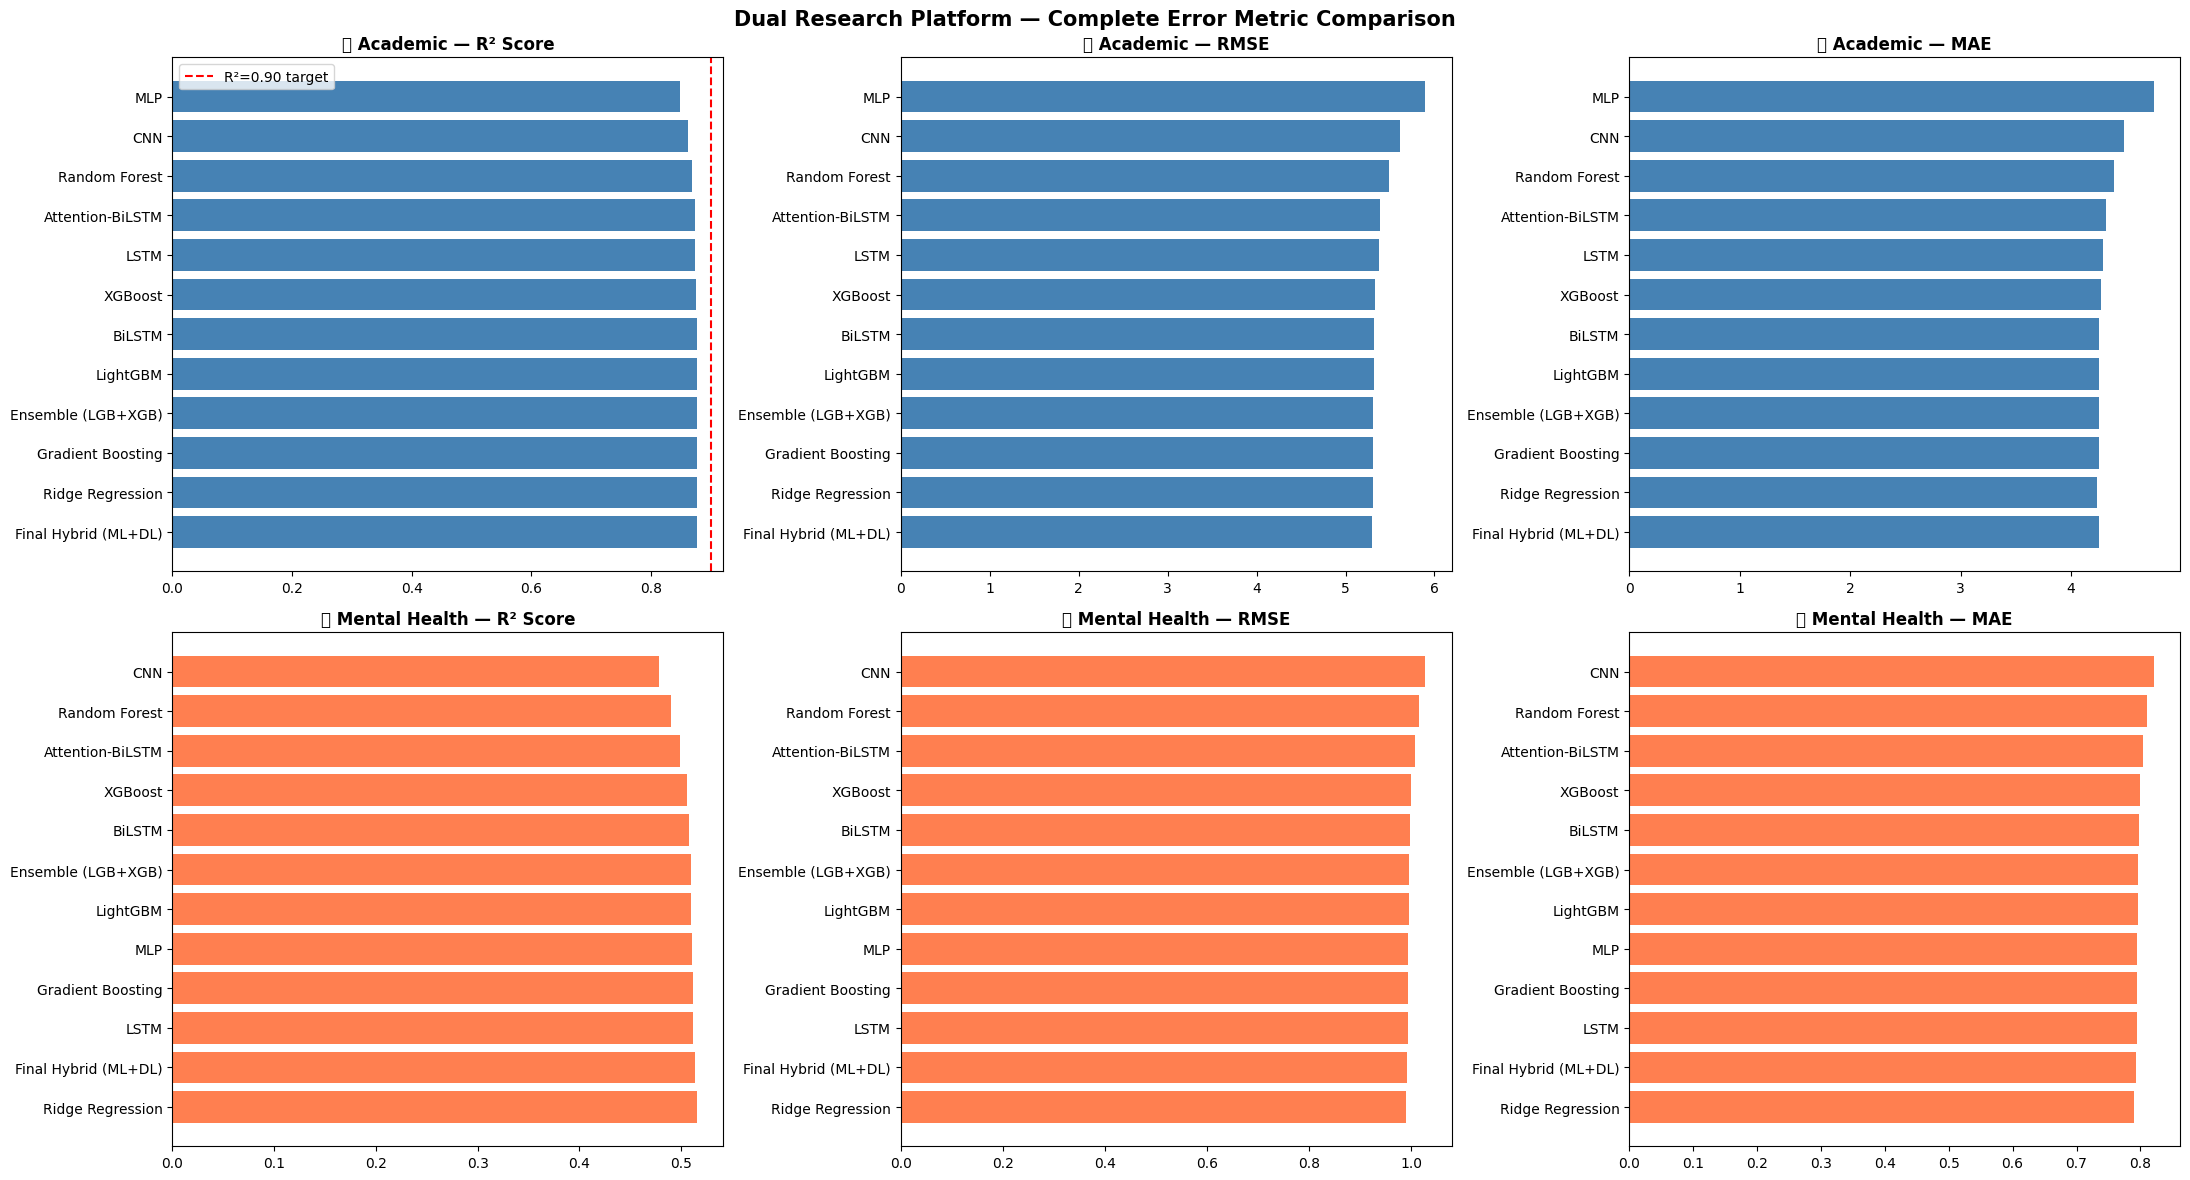


🏆 PLATFORM 1 — BEST MODEL
  Model : Final Hybrid (ML+DL)
  R²    : 0.8768
  RMSE  : 5.3026
  MAE   : 4.2472
  MSE   : 28.1180

🏆 PLATFORM 2 — BEST MODEL
  Model : Ridge Regression
  R²    : 0.5156
  RMSE  : 0.9900
  MAE   : 0.7903
  MSE   : 0.9800


In [ ]:
p1 = pd.read_csv('platform1_results.csv')
p2 = pd.read_csv('platform2_results.csv')

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# Platform 1
axes[0, 0].barh(p1['Model'], p1['R2'], color='steelblue')
axes[0, 0].axvline(0.90, color='red', linestyle='--', lw=1.5, label='R²=0.90 target')
axes[0, 0].set_title('🎓 Academic — R² Score', fontweight='bold'); axes[0, 0].legend()

axes[0, 1].barh(p1['Model'], p1['RMSE'], color='steelblue')
axes[0, 1].set_title('🎓 Academic — RMSE', fontweight='bold')

axes[0, 2].barh(p1['Model'], p1['MAE'], color='steelblue')
axes[0, 2].set_title('🎓 Academic — MAE', fontweight='bold')

# Platform 2
axes[1, 0].barh(p2['Model'], p2['R2'], color='coral')
axes[1, 0].set_title('🧠 Mental Health — R² Score', fontweight='bold')

axes[1, 1].barh(p2['Model'], p2['RMSE'], color='coral')
axes[1, 1].set_title('🧠 Mental Health — RMSE', fontweight='bold')

axes[1, 2].barh(p2['Model'], p2['MAE'], color='coral')
axes[1, 2].set_title('🧠 Mental Health — MAE', fontweight='bold')

plt.suptitle('Dual Research Platform — Complete Error Metric Comparison',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


print(" PLATFORM 1 — BEST MODEL")
best1 = p1.iloc[0]
print(f"  Model : {best1['Model']}")
print(f"  R²    : {best1['R2']:.4f}")
print(f"  RMSE  : {best1['RMSE']:.4f}")
print(f"  MAE   : {best1['MAE']:.4f}")
print(f"  MSE   : {best1['MSE']:.4f}")

print("\n PLATFORM 2 — BEST MODEL")
best2 = p2.iloc[0]
print(f"  Model : {best2['Model']}")
print(f"  R²    : {best2['R2']:.4f}")
print(f"  RMSE  : {best2['RMSE']:.4f}")
print(f"  MAE   : {best2['MAE']:.4f}")
print(f"  MSE   : {best2['MSE']:.4f}")
